In [1]:
# Official packages
import os
import copy
import math
import re

from pprint import pprint
from itertools import chain

# Third-party packages
import numpy as np
#import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.cm as cm

# In-house packages
from BrukerPV360 import BrukerPV360Exp




In [2]:
raw_path = "./TestData/BrukerPV360/PRESS"

a = BrukerPV360Exp(raw_path, is_verbose=False)



<function matplotlib.pyplot.show(close=None, block=None)>

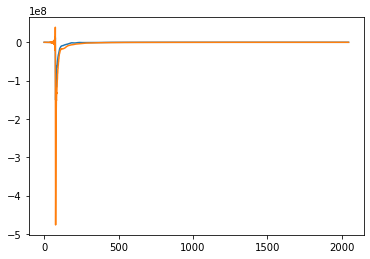

In [3]:
FID = a.dataset['DATA']['rawdata'][0]
plt.plot(np.real(FID))
plt.plot(np.imag(FID))
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

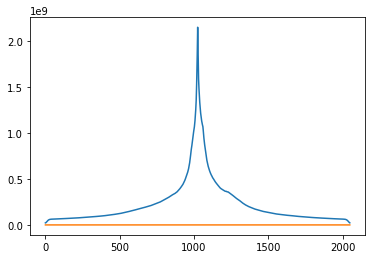

In [4]:
SPEC = a.dataset['DATA']['2dseq'][0]
plt.plot(np.real(SPEC))
plt.plot(np.imag(SPEC))
plt.show

In [5]:
raw_path = "./TestData/BrukerPV360/T2wRARE"

a = BrukerPV360Exp(raw_path, is_verbose=False)



<function matplotlib.pyplot.show(close=None, block=None)>

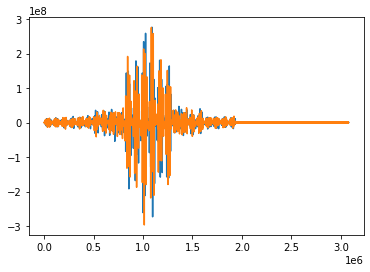

In [6]:
FID = a.dataset['DATA']['rawdata'][0]
plt.plot(np.real(FID))
plt.plot(np.imag(FID))
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

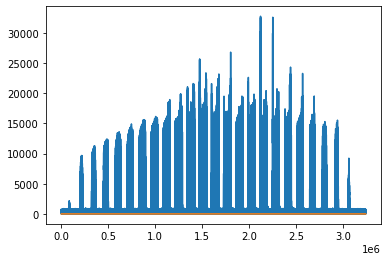

In [7]:
SPEC = a.dataset['DATA']['2dseq'][0]
plt.figure()
plt.plot(np.real(SPEC))
plt.plot(np.imag(SPEC))
plt.show



<function matplotlib.pyplot.show(close=None, block=None)>

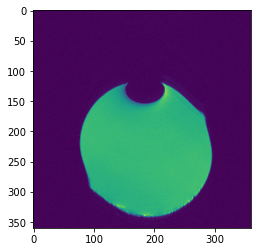

In [8]:
img_mat = [int(x) for x in a.dataset['PARAM']['method'][0]['PVM_Matrix']]
nbr_slice = int(a.dataset['PARAM']['acqp'][0]['NSLICES'])

SPEC = np.reshape(SPEC, (nbr_slice,img_mat[0],img_mat[1]))

plt.figure()
plt.imshow((np.real(SPEC[12])))
plt.show

In [9]:
raw_path = "./TestData/BrukerPV360/CSI_PLUS_NR15"

a = BrukerPV360Exp(raw_path, is_verbose=False)


<function matplotlib.pyplot.show(close=None, block=None)>

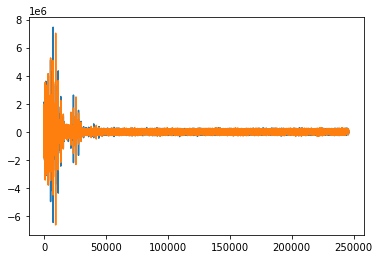

In [10]:
FID = a.dataset['DATA']['rawdata'][0]
plt.plot(np.real(FID))
plt.plot(np.imag(FID))
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

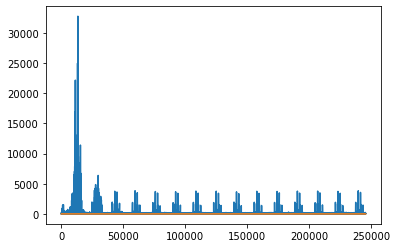

In [11]:
SPEC = a.dataset['DATA']['2dseq'][0]
plt.figure()
plt.plot(np.real(SPEC))
plt.plot(np.imag(SPEC))
plt.show



<function matplotlib.pyplot.show(close=None, block=None)>

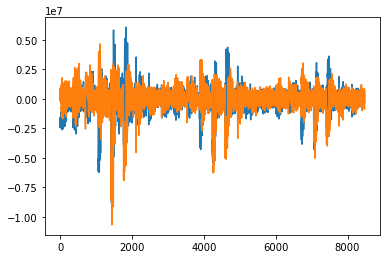

In [12]:
raw_path = "TestData/BrukerPV360/hpBssfpSpiral3d3Rep1Intlv"

a = BrukerPV360Exp(raw_path, is_verbose=False)

FID = a.dataset['DATA']['rawdata'][0]
plt.plot(np.real(FID))
plt.plot(np.imag(FID))
plt.show

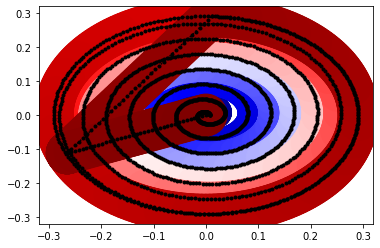

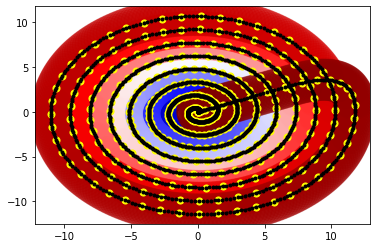

True

In [17]:
spiral_x = (a.dataset['PARAM']['method'][0]['PVM_SpiralShape1'])
spiral_y = (a.dataset['PARAM']['method'][0]['PVM_SpiralShape2'])
 
spiral = spiral_x + 1j * spiral_y

plt.figure()
plt.scatter(spiral_x, spiral_y, c=(range(len(spiral_x))), s=(range(len(spiral_x))), cmap='seismic')
plt.plot(spiral_x, spiral_y, c= "black", marker='.', linestyle=':')
plt.show()

traj = np.cumsum(spiral)
traj_ro = traj[::5]

plt.figure()
plt.scatter(np.cumsum(spiral_x), np.cumsum(spiral_y), c=(range(len(spiral_x))), s=(range(len(spiral_x))), cmap='seismic', alpha=.3)
plt.plot(np.cumsum(spiral_x), np.cumsum(spiral_y), c= "black", marker='.', linestyle=':')
plt.scatter(np.real(traj_ro),np.imag(traj_ro), c='yellow', s=50)
plt.show()

len(traj_ro) == a.dataset['PARAM']['method'][0]['PVM_SpiralNbOfAcqPoints']



(24, 353)


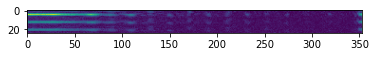

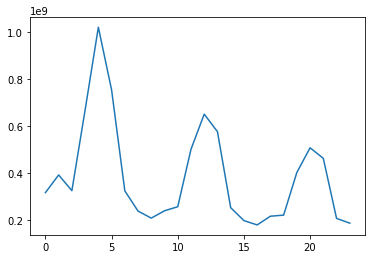

In [28]:
FID = np.reshape(FID, [-1, a.dataset['PARAM']['method'][0]['PVM_SpiralNbOfAcqPoints']])
print(np.shape(FID))
plt.figure()
plt.imshow(np.abs(FID))
plt.show()

plt.figure()
plt.plot(np.sum(np.abs(FID), axis=1))
plt.show()

In [35]:
import pynufft

pynufft.tests.test_init()

AttributeError: module 'pynufft' has no attribute 'tests'